# Grid MADRL Mainline

This notebook keeps the main workflow short: configure -> train -> test -> compare with MPC.


In [1]:
from pathlib import Path
import sys
import warnings

try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / 'configs').exists():
    project_root = project_root.parent
if not (project_root / 'configs').exists():
    raise RuntimeError('Could not locate the project root.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Python executable: {sys.executable}')
try:
    import gymnasium as gym
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "Gymnasium is required for this notebook. Install gymnasium==0.29.1 in the active kernel environment."
    ) from exc
print(f'Gymnasium version: {gym.__version__}')

warnings.filterwarnings('ignore', message='The behavior of DataFrame concatenation with empty or all-NA entries is deprecated.*')
project_root


Python executable: d:\SOFTWARE\miniconda\envs\MADRL_ESS\python.exe
Gymnasium version: 0.29.1


WindowsPath('D:/GithubProject/MADRL_ESS')

In [2]:
import os

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

import torch

torch.set_num_threads(1)

from configs import compose_experiment_config, recommended_gpu_fast_num_envs
from scripts.plots.reward_plots import plot_reward_decomposition
from scripts.utils.experiment_notebook_utils import build_runner, get_madrl_checkpoint_root, summarize_cfg
from scripts.utils.grid_notebook_workflow import (
    apply_notebook_experiment_settings,
    build_comparison_cfg,
    collect_madrl_rollout,
    collect_mpc_rollout,
    compare_operating_costs,
    ensure_forecast_ready,
    plot_operating_cost_comparison,
    plot_test_rollout,
)
from scripts.utils.train_mainline_launcher import run_external_train_mainline
from scripts.utils.torch_runtime import configure_torch_runtime, describe_device


In [3]:
experiment_controls = {
    "algorithm": "MATD3",
    "reward_plot_window": 10,
    "seed": 7,
    "runtime_mode": "performance",
    "device_request": "cuda" if torch.cuda.is_available() else "cpu",
    "require_cuda": bool(torch.cuda.is_available()),
}

data_controls = {
    "prediction_mode": "perfect",  # 'perfect' or 'normal'
    "test_start_date": 20200101,
    "test_end_date": 20200103,
    "agent_profiles": ["SFH12", "SFH14", "SFH16"],
    "load_scale": [1.0, 1.0, 1.0],
    "pv_scale": [1.0, 1.0, 1.0],
    "storage_scale": [1.0, 1.0, 1.0],
    "future_horizon": 24,
    "train_year": 2019,
    "test_year": 2020,
}

train_controls = {
    "launch_mode": "external",  # 'external' or 'inline'
    "profile": "gpu_fast",
    "model_family": "mlp",
    "num_envs": recommended_gpu_fast_num_envs(),
    "vec_env_type": "subproc",
    "train_episodes": 100,
    "batch_size": 4096,
    "buffer_size": 200000,
    "update_interval": 1,
    "updates_per_step": 2,
    "policy_update_freq": 2,
    "use_noise_decay": True,
    "show_progress": True,
    "progress_postfix_interval": 10,
    "noise_std_init": 0.35,
    "noise_std_min": 0.05,
    "max_train_steps": None,
}

launch_mode = train_controls["launch_mode"]
reward_plot_window = experiment_controls["reward_plot_window"]
seed = experiment_controls["seed"]
train_env_name = "GridTrainMainline"
train_run_number = 1

cfg = compose_experiment_config(
    profile=train_controls["profile"],
    algorithm=experiment_controls["algorithm"],
    model_family=train_controls["model_family"],
    vec_env_type=train_controls["vec_env_type"],
    data_dir=project_root / "data",
    device=experiment_controls["device_request"],
    runtime_mode=experiment_controls["runtime_mode"],
    seed=seed,
    require_cuda=experiment_controls["require_cuda"],
)

applied_controls = apply_notebook_experiment_settings(
    cfg,
    prediction_mode=data_controls["prediction_mode"],
    test_start_date=data_controls["test_start_date"],
    test_end_date=data_controls["test_end_date"],
    agent_profiles=data_controls["agent_profiles"],
    load_scale=data_controls["load_scale"],
    pv_scale=data_controls["pv_scale"],
    storage_scale=data_controls["storage_scale"],
    future_horizon=data_controls["future_horizon"],
    train_year=data_controls["train_year"],
    test_year=data_controls["test_year"],
)

cfg.train.train_episodes = train_controls["train_episodes"]
cfg.train.num_envs = train_controls["num_envs"]
cfg.train.vec_env_type = train_controls["vec_env_type"]
cfg.train.batch_size = train_controls["batch_size"]
cfg.train.buffer_size = train_controls["buffer_size"]
cfg.train.update_interval = train_controls["update_interval"]
cfg.train.updates_per_step = train_controls["updates_per_step"]
cfg.train.use_noise_decay = train_controls["use_noise_decay"]
cfg.train.show_progress = train_controls["show_progress"]
cfg.train.progress_postfix_interval = train_controls["progress_postfix_interval"]
cfg.train.noise_std_init = train_controls["noise_std_init"]
cfg.train.noise_std_min = train_controls["noise_std_min"]
cfg.train.max_train_steps = train_controls["max_train_steps"]
cfg.algo.policy_update_freq = train_controls["policy_update_freq"]
cfg.train.noise_decay_steps = cfg.train.train_episodes * cfg.env.episode_limit

runtime_state = configure_torch_runtime(
    cfg,
    device=experiment_controls["device_request"],
    seed=seed,
    require_cuda=experiment_controls["require_cuda"],
)
forecast_ready = ensure_forecast_ready(cfg)
algorithm = cfg.algo.name
summary = summarize_cfg(cfg)
summary["device_info"] = describe_device(runtime_state)
summary["experiment_controls"] = experiment_controls
summary["data_controls"] = data_controls
summary["train_controls"] = train_controls
summary["applied_controls"] = applied_controls
summary["forecast_ready"] = forecast_ready
summary["launch_mode"] = launch_mode
summary


{'agent_profiles': ['SFH12', 'SFH14', 'SFH16'],
 'algo': 'MATD3',
 'batch_size': 4096,
 'data_dir': 'D:\\GithubProject\\MADRL_ESS\\data',
 'device': 'cuda:0',
 'episode_limit': 192,
 'expected_completed_episodes_floor': 100,
 'forecast': 'perfect',
 'future_horizon': 24,
 'grid_agent_bus_ids': [10, 6, 12],
 'grid_sb_code': '1-LV-rural1--0-sw',
 'load_scale': [1.0, 1.0, 1.0],
 'local_features': ['time', 'soc'],
 'max_train_steps': None,
 'model_family': 'mlp',
 'num_envs': 20,
 'parallel_rollout_iterations': 960,
 'partial_steps_per_env_at_stop': 0,
 'pv_scale': [1.0, 1.0, 1.0],
 'resolved_train_steps': 19200,
 'reward': 'grid_composite',
 'runtime_mode': 'performance',
 'seed': 7,
 'sequence_features': ['price', 'load', 'pv'],
 'storage_scale': [1.0, 1.0, 1.0],
 'test_end_date': '2020-01-03',
 'test_start_date': '2020-01-01',
 'test_year': 2020,
 'train_budget_source': 'train_episodes * episode_limit',
 'train_end_date': None,
 'train_episodes': 100,
 'train_start_date': None,
 'train_

{'algo': 'MATD3',
 'model_family': 'mlp',
 'reward': 'grid_composite',
 'forecast': 'perfect',
 'local_features': ['time', 'soc'],
 'sequence_features': ['price', 'load', 'pv'],
 'vec_env': 'subproc',
 'num_envs': 20,
 'batch_size': 4096,
 'train_episodes': 100,
 'episode_limit': 192,
 'future_horizon': 24,
 'max_train_steps': None,
 'resolved_train_steps': 19200,
 'parallel_rollout_iterations': 960,
 'expected_completed_episodes_floor': 100,
 'partial_steps_per_env_at_stop': 0,
 'train_budget_source': 'train_episodes * episode_limit',
 'device': 'cuda:0',
 'runtime_mode': 'performance',
 'seed': 7,
 'data_dir': 'D:\\GithubProject\\MADRL_ESS\\data',
 'grid_sb_code': '1-LV-rural1--0-sw',
 'grid_agent_bus_ids': [10, 6, 12],
 'train_year': 2019,
 'test_year': 2020,
 'train_start_date': None,
 'train_end_date': None,
 'test_start_date': '2020-01-01',
 'test_end_date': '2020-01-03',
 'agent_profiles': ['SFH12', 'SFH14', 'SFH16'],
 'load_scale': [1.0, 1.0, 1.0],
 'pv_scale': [1.0, 1.0, 1.0],

In [4]:
runner = None
train_result = None
launch_metadata = None
save_dir = None

if launch_mode == "external":
    launch_metadata = run_external_train_mainline(
        project_root=project_root,
        experiment_controls=experiment_controls,
        data_controls=data_controls,
        train_controls=train_controls,
        data_dir=project_root / "data",
        env_name=train_env_name,
        run_number=train_run_number,
    )
    train_result = launch_metadata["result"] or {}
    algorithm = train_result.get("algorithm", cfg.algo.name)
    episodes_completed = int(train_result["episodes_completed"])
    save_dir = Path(train_result["save_dir"])
    print(f"External training finished: {episodes_completed} episodes")
    print(f"Device: {train_result['device']}")
    print(f"Vec env: {train_result['vec_env']}")
    print(f"TensorBoard: {train_result['tensorboard_dir']}")
    print(f"Checkpoint dir: {save_dir}")
    print(f"Child pid: {launch_metadata['pid']}, returncode: {launch_metadata['returncode']}")
    train_result
else:
    runner = build_runner(cfg, seed=seed, env_name=train_env_name, number=train_run_number)
    episodes_completed = runner.run()
    save_dir = get_madrl_checkpoint_root(project_root) / f'{algorithm}_Grid_Mainline'
    print(f'Training finished: {episodes_completed} episodes')
    runner.perf_summary


{'agent_profiles': ['SFH12', 'SFH14', 'SFH16'],
 'algo': 'MATD3',
 'batch_size': 4096,
 'data_dir': 'D:\\GithubProject\\MADRL_ESS\\data',
 'device': 'cuda:0',
 'episode_limit': 192,
 'expected_completed_episodes_floor': 100,
 'forecast': 'perfect',
 'future_horizon': 24,
 'grid_agent_bus_ids': [10, 6, 12],
 'grid_sb_code': '1-LV-rural1--0-sw',
 'load_scale': [1.0, 1.0, 1.0],
 'local_features': ['time', 'soc'],
 'max_train_steps': None,
 'model_family': 'mlp',
 'num_envs': 20,
 'parallel_rollout_iterations': 960,
 'partial_steps_per_env_at_stop': 0,
 'pv_scale': [1.0, 1.0, 1.0],
 'resolved_train_steps': 19200,
 'reward': 'grid_composite',
 'runtime_mode': 'performance',
 'seed': 7,
 'sequence_features': ['price', 'load', 'pv'],
 'storage_scale': [1.0, 1.0, 1.0],
 'test_end_date': '2020-01-03',
 'test_start_date': '2020-01-01',
 'test_year': 2020,
 'train_budget_source': 'train_episodes * episode_limit',
 'train_end_date': None,
 'train_episodes': 100,
 'train_start_date': None,
 'train_

In [5]:
if launch_mode == "inline":
    plot_reward_decomposition(
        history=list(runner.history),
        episode_rewards=runner.episode_rewards,
        reward_fn=runner.env_evaluate.reward_fn,
        title='Training Reward Decomposition',
        window=reward_plot_window,
    )
else:
    print('Reward decomposition is available only for inline smoke runs; external training does not keep runner.history in notebook memory.')


Reward decomposition is available only for inline smoke runs; external training does not keep runner.history in notebook memory.


In [6]:
if launch_mode == "inline":
    save_dir = get_madrl_checkpoint_root(project_root) / f'{algorithm}_Grid_Mainline'
    save_dir.mkdir(parents=True, exist_ok=True)
    runner.save_model(str(save_dir), episode=episodes_completed)
    runner.close()
    print(f'Model saved to: {save_dir}')
else:
    print(f'External mainline already saved the model to: {save_dir}')


External mainline already saved the model to: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3_Grid_Mainline


In [7]:
cfg.algo.name = algorithm

drl_rollout = collect_madrl_rollout(
    cfg,
    model_root=save_dir,
    algorithm=algorithm,
    episode_tag=episodes_completed,
)
cost_summary = drl_rollout.summary
cost_summary


,controller,agent_profile,operating_cost
0,DRL (perfect),SFH12,-0.056715
1,DRL (perfect),SFH14,3.788384
2,DRL (perfect),SFH16,2.250203


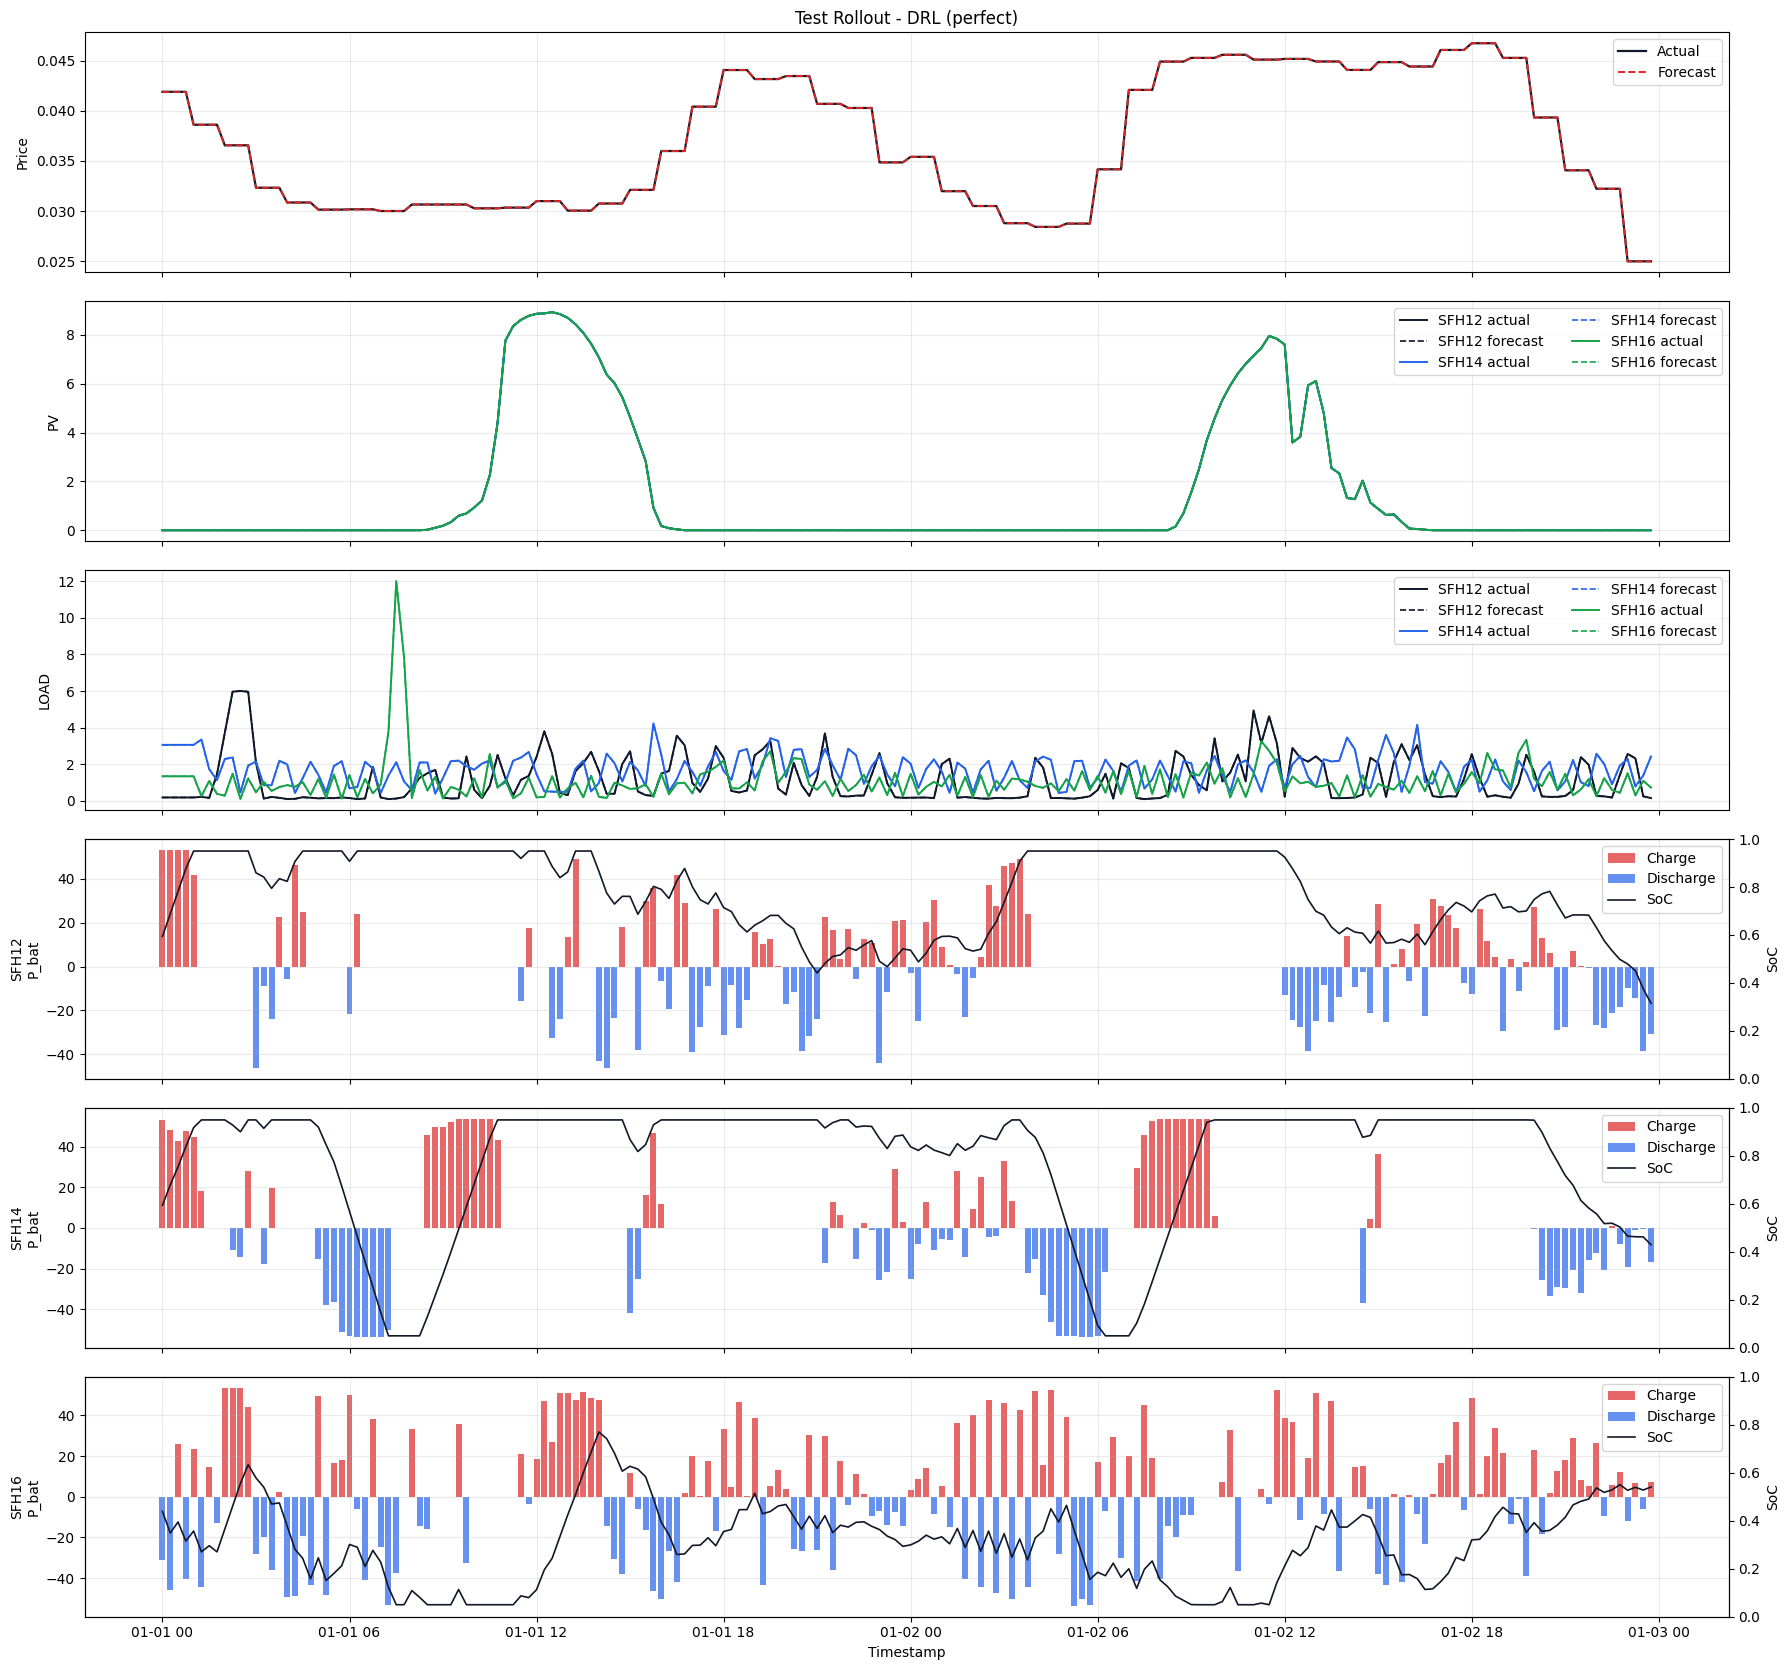

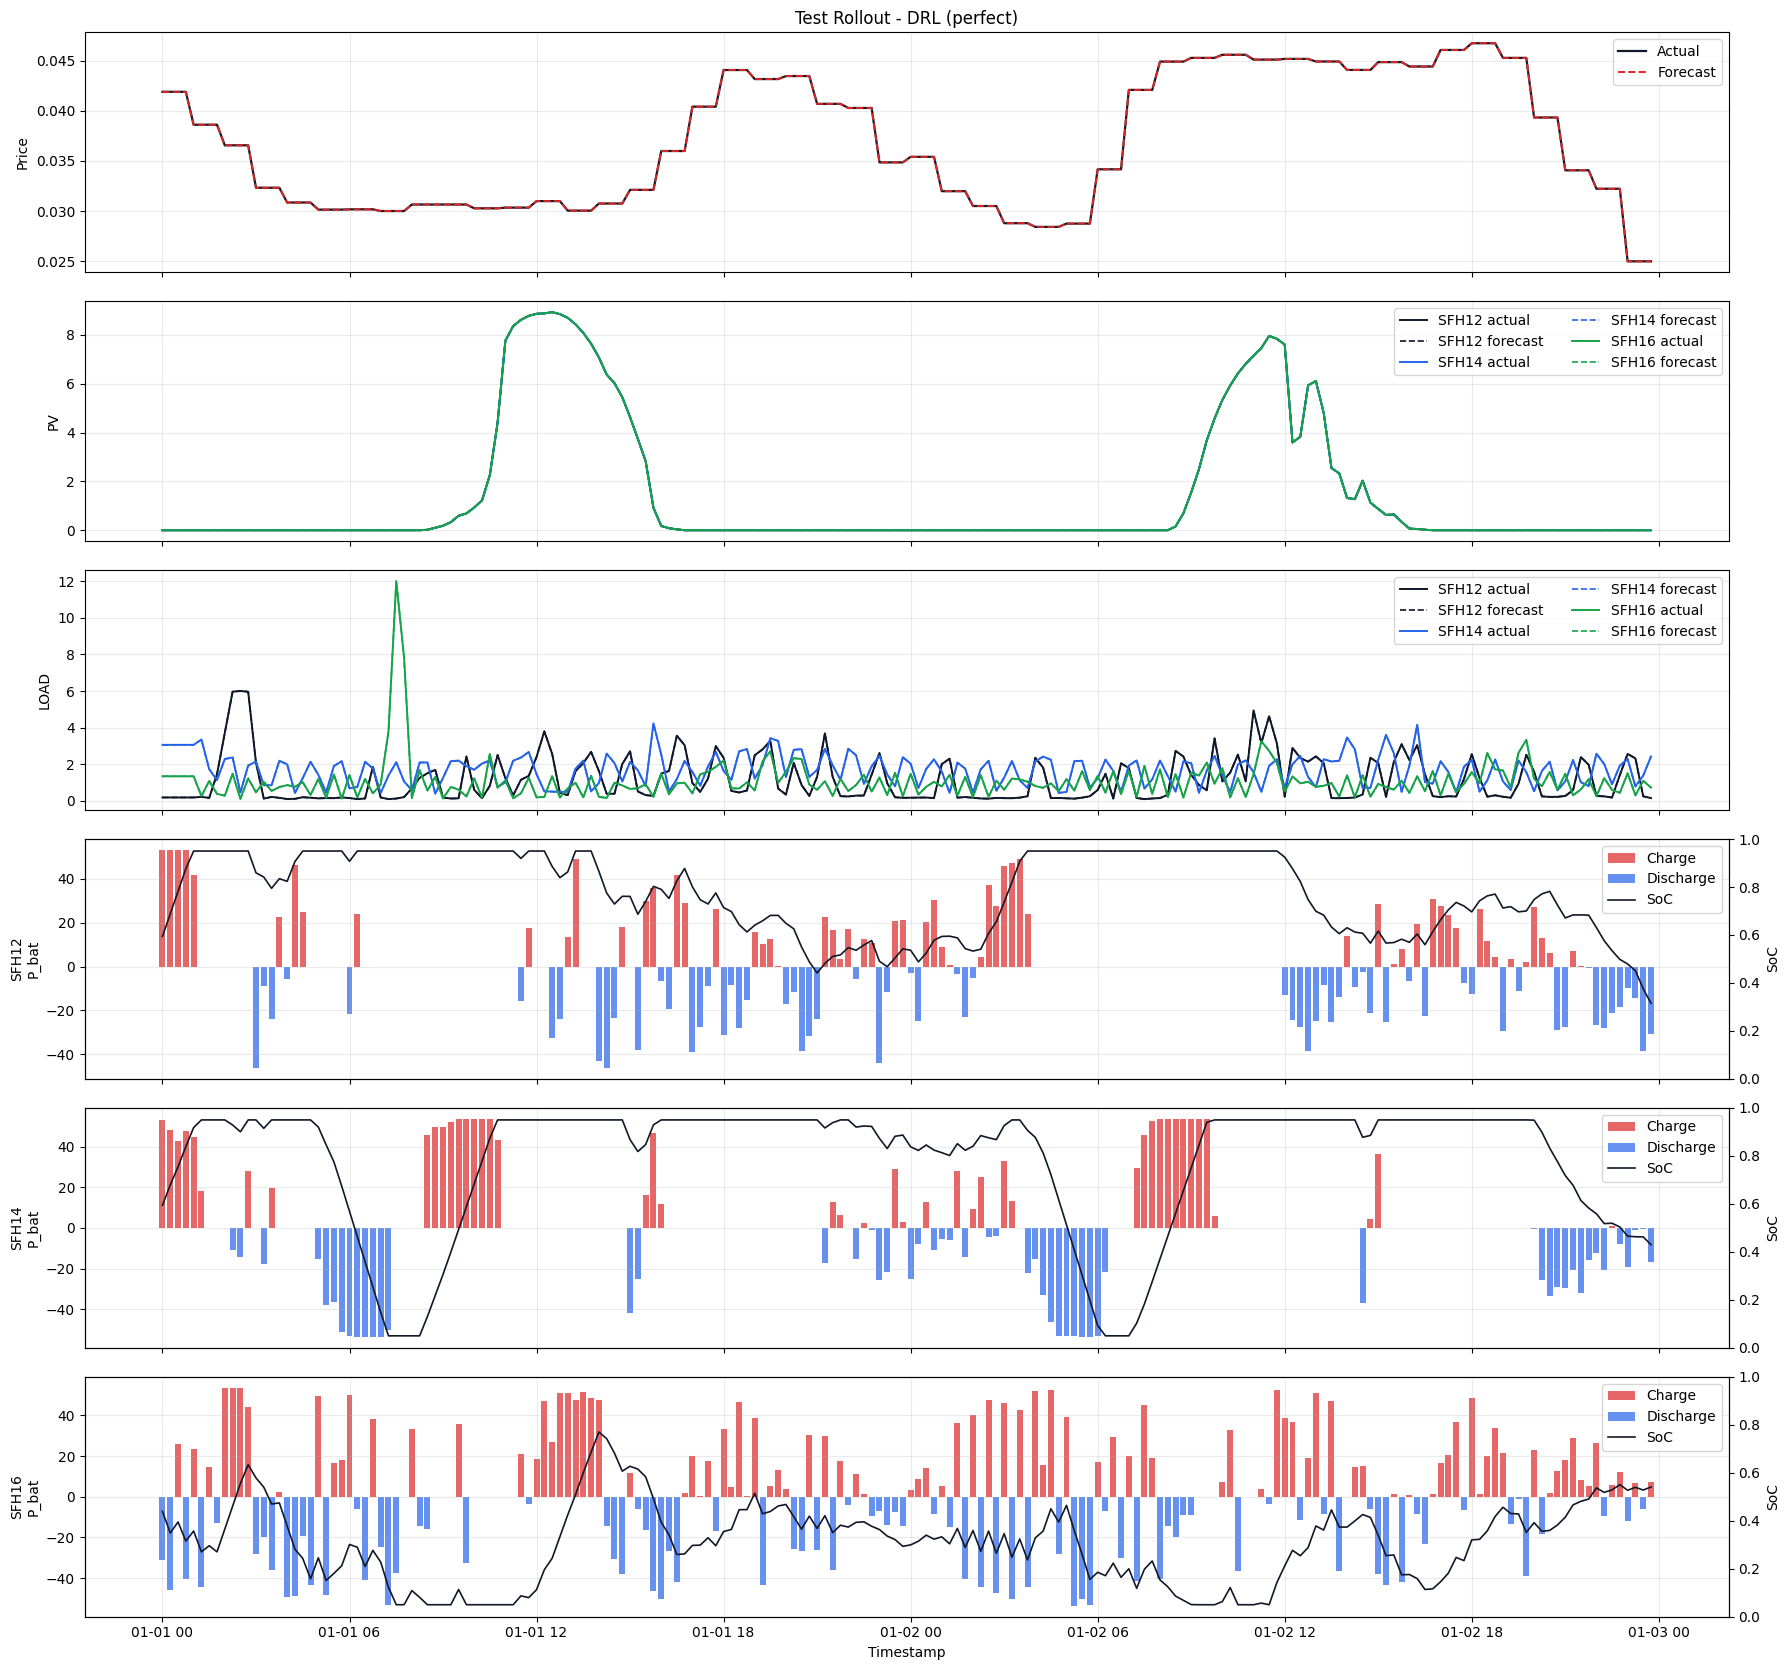

In [8]:
plot_test_rollout(drl_rollout)


In [9]:
normal_mpc_cfg = build_comparison_cfg(cfg, prediction_mode='normal')
normal_forecast_ready = ensure_forecast_ready(normal_mpc_cfg)

mpc_normal_rollout = collect_mpc_rollout(cfg, prediction_mode='normal', label='MPC (normal)')
mpc_perfect_rollout = collect_mpc_rollout(cfg, prediction_mode='perfect', label='MPC (perfect)')
cost_comparison = compare_operating_costs(mpc_normal_rollout, mpc_perfect_rollout, drl_rollout)
cost_comparison


[forecast] artifact mismatch detected: signal='price', artifact='D:\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\price\price_lstm_h24.pt', 配置不一致: dropout(expected=0.0, actual=0.1), hidden_size(expected=64, actual=128), num_layers(expected=1, actual=2), seq_len(expected=96, actual=672). 建议删除旧 artifact，或开启 cfg.forecast.auto_train_missing=True 自动重训。
[forecast] retraining signal=price
[forecast] price: train_segments=1, val_segments=1, columns=['price'], train_stats={'min': -0.09001000225543976, 'max': 0.12145999819040298, 'mean': 0.038191478699445724, 'std': 0.015919901430606842}, settings={'signal_name': 'price', 'history_window': 96, 'future_horizon': 24, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'batch_size': 512, 'epochs': 4, 'lr': 0.001, 'train_ratio': 0.7, 'val_ratio': 0.15, 'device': 'cuda:0'}
[forecast] artifact refreshed at D:\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\price\price_lstm_h24.pt
[forecast] price metrics: online_rmse=0.002688, online_mae=0.0

,controller,total_operating_cost
0,MPC (perfect),-15.146281
1,MPC (normal),-1.398316
2,DRL (perfect),5.981872


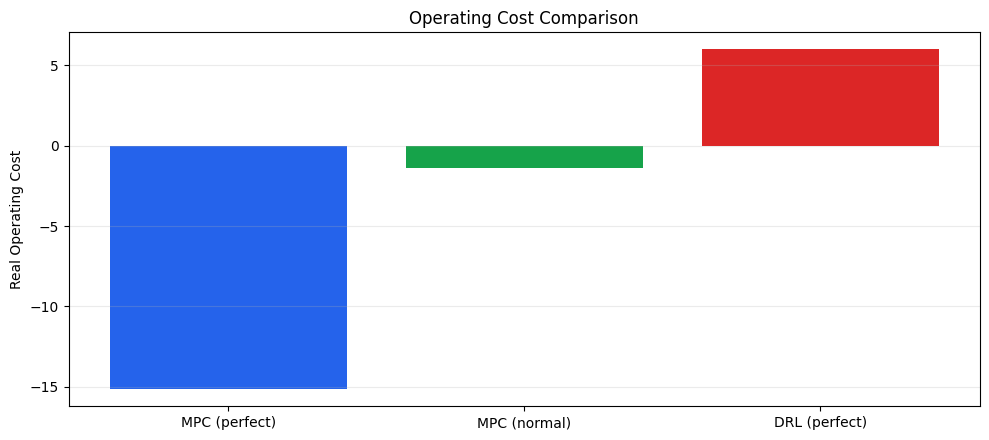

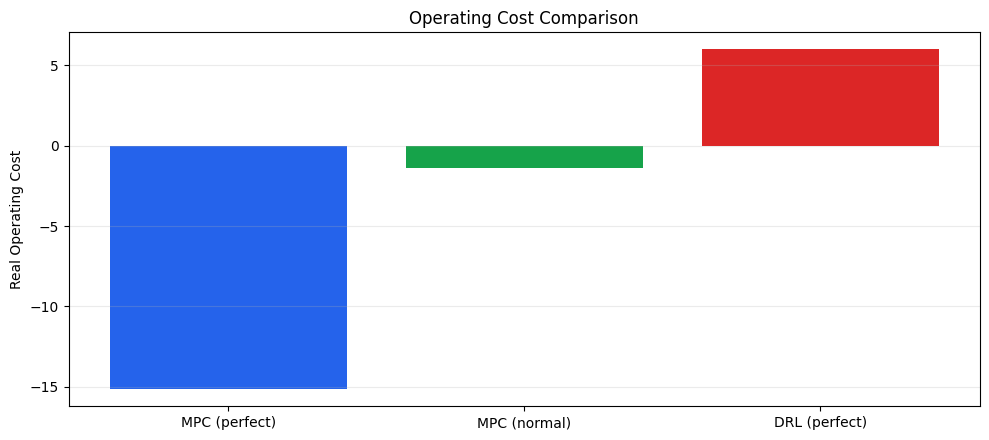

In [10]:
plot_operating_cost_comparison(cost_comparison)
